![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import statistics

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [3]:
beer = pd.read_csv("data/datasets_beers.csv")
#imprimir los primeros registros
beer.head()

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


In [4]:
beer.columns

Index(['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id',
       'ounces'],
      dtype='object')

In [5]:
beer.ndim

2

In [6]:
beer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2410 non-null   int64  
 1   abv         2348 non-null   float64
 2   ibu         1405 non-null   float64
 3   id          2410 non-null   int64  
 4   name        2410 non-null   object 
 5   style       2405 non-null   object 
 6   brewery_id  2410 non-null   int64  
 7   ounces      2410 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 150.8+ KB


In [7]:
beer.describe()

,Unnamed: 0,abv,ibu,id,brewery_id,ounces
count,2410.000000,2348.000000,1405.000000,2410.000000,2410.000000,2410.000000
mean,1204.500000,0.059773,42.713167,1431.113278,231.749793,13.592241
std,695.851397,0.013542,25.954066,752.459975,157.685604,2.352204
min,0.000000,0.001000,4.000000,1.000000,0.000000,8.400000
25%,602.250000,0.050000,21.000000,808.250000,93.000000,12.000000
50%,1204.500000,0.056000,35.000000,1453.500000,205.000000,12.000000
75%,1806.750000,0.067000,64.000000,2075.750000,366.000000,16.000000
max,2409.000000,0.128000,138.000000,2692.000000,557.000000,32.000000


## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [8]:
beer=beer.drop(columns="Unnamed: 0")
#Esta columna era el atiguo indice, se ha gusdado en un DF como csv y aparece estanueva columna (como era posiciones sin mas no es relevante)
#al leer el csv : x=pd.read_csv("csv", index_col=0)


In [9]:
beer

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [10]:
beer.shape

(2410, 7)

## Ejercicio 5
¿De qué tipo son los datos?

In [11]:
beer.dtypes

abv           float64
ibu           float64
id              int64
name           object
style          object
brewery_id      int64
ounces        float64
dtype: object

## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [12]:
beer[["ibu","abv","ounces"]].describe()

,ibu,abv,ounces
count,1405.000000,2348.000000,2410.000000
mean,42.713167,0.059773,13.592241
std,25.954066,0.013542,2.352204
min,4.000000,0.001000,8.400000
25%,21.000000,0.050000,12.000000
50%,35.000000,0.056000,12.000000
75%,64.000000,0.067000,16.000000
max,138.000000,0.128000,32.000000


In [46]:
beer[["ibu","abv","ounces"]].agg(["count","mean"])

,ibu,abv,ounces
count,1405.000000,2348.000000,2410.000000
mean,42.713167,0.059773,13.592241


In [47]:
beer.aggregate({"abv":"mean", "ibu":["median","count"]})

,abv,ibu
mean,0.059773,NaN
median,NaN,35.0
count,NaN,1405.0


In [49]:
beer.describe(include="all")

,abv,ibu,id,name,style,brewery_id,ounces
count,2348.000000,1405.000000,2410.000000,2410,2405,2410.000000,2410.000000
unique,NaN,NaN,NaN,2305,99,NaN,NaN
top,NaN,NaN,NaN,Nonstop Hef Hop,American IPA,NaN,NaN
freq,NaN,NaN,NaN,12,424,NaN,NaN
mean,0.059773,42.713167,1431.113278,NaN,NaN,231.749793,13.592241
std,0.013542,25.954066,752.459975,NaN,NaN,157.685604,2.352204
min,0.001000,4.000000,1.000000,NaN,NaN,0.000000,8.400000
25%,0.050000,21.000000,808.250000,NaN,NaN,93.000000,12.000000
50%,0.056000,35.000000,1453.500000,NaN,NaN,205.000000,12.000000
75%,0.067000,64.000000,2075.750000,NaN,NaN,366.000000,16.000000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [13]:
#Return Series with duplicate values removed(len cuenta los Nan)
len(beer["style"].drop_duplicates())

100

In [55]:
len(beer["style"].unique())

100

In [51]:
#Return a Series containing counts of unique values.(no cuenta Nan, por eso varia en la length)
'''Muestra el valor absoluto ya ordenado'''
beer["style"].value_counts()
#si quiero que me lo cuente le doy un valor concreto: beer["style"].fillna("Missing values" = Nan)
#al darle un estlo al Nan ya me lo va a contar

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
Wheat Ale                           1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

In [53]:
#sacar las frecuencias relativas, normalizar datos
beer["style"].value_counts(normalize=True)[:10]#de las 10 primeras

style
American IPA                      0.176299
American Pale Ale (APA)           0.101871
American Amber / Red Ale          0.055301
American Blonde Ale               0.044906
American Double / Imperial IPA    0.043659
American Pale Wheat Ale           0.040333
American Brown Ale                0.029106
American Porter                   0.028274
Saison / Farmhouse Ale            0.021622
Witbier                           0.021206
Name: proportion, dtype: float64

In [54]:
beer.groupby("style")["id"].count().sort_values(ascending=False)
#agrupame los estilos y saca un conteo de identificadores. Ordenalos de mayor a menor

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
Kristalweizen                       1
Other                               1
Low Alcohol Beer                    1
Smoked Beer                         1
Wheat Ale                           1
Name: id, Length: 99, dtype: int64

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [58]:
beer.loc[9:19,"name":"ounces"]

,name,style,brewery_id,ounces
9,Cone Crusher,American Double / Imperial IPA,177,12.0
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0


In [59]:
beer.loc[9:20,["abv","ibu","ounces"]].to_numpy()#lo pasamos a un array


array([[ 0.086,    nan, 12.   ],
       [ 0.072,    nan, 12.   ],
       [ 0.073,    nan, 12.   ],
       [ 0.069,    nan, 12.   ],
       [ 0.085,    nan, 12.   ],
       [ 0.061, 60.   , 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.082,    nan, 12.   ],
       [ 0.082,    nan, 12.   ]])

In [68]:
list(beer.columns).index("name")

3

## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [74]:
beer["style"].fillna("Missing values")
beer[~beer["style"].str.contains("Cider")]["ounces"].sum()#sumamos solo las cervezas, sin las sidras
'''Si tengo NAn no me sale, tengo que hacer el missing style=Nan'''

TypeError: bad operand type for unary ~: 'float'

In [17]:
beer["ounces"].sum()

np.float64(32757.3)

## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [75]:
len(beer[beer["ibu"].isnull()])/len(beer)# %valores nulos en ibu

0.4170124481327801

In [18]:
beer["ibu"].min()

np.float64(4.0)

In [19]:
beer["ibu"].max()

np.float64(138.0)

In [20]:
beer["ibu"].mean()


np.float64(42.71316725978647)

In [76]:
beer[beer["ibu"]==beer["ibu"].min()]#cerveza con amargor minimo

,abv,ibu,id,name,style,brewery_id,ounces
106,0.056,4.0,1350,Summer Solstice,Cream Ale,171,12.0
112,0.056,4.0,753,Summer Solstice Cerveza Crema (2009),Cream Ale,171,12.0
117,0.056,4.0,77,Summer Solstice (2011),Cream Ale,171,12.0


In [22]:
beer[beer["ibu"]==beer["ibu"].max()]["name"]#cerveza con amargor maximo

147    Bitter Bitch Imperial IPA
Name: name, dtype: object

In [77]:
#Faltan un 40% de los datos: relleno los vacios y los suponemos como la media de los datos
beer["ibu"].fillna(beer["ibu"].mean())
beer["ibu"].fillna(beer["ibu"].mode()[0])
beer["ibu"].fillna(beer["ibu"].median()[0])
#asi modificaremos mucho los valores estadisticos. Como tenemos una desviacion estandar alta no podemos llenar los nulos con valores medios

0       42.713167
1       42.713167
2       42.713167
3       42.713167
4       42.713167
          ...    
2405    45.000000
2406    42.713167
2407    42.713167
2408    40.000000
2409    42.713167
Name: ibu, Length: 2410, dtype: float64

In [79]:
#haciendo la media de los amargores por estilo podemos consegui un resultado mas acertado
mediana_ibu_style= beer.groupby("style")[["ibu"]].mean()
mediana_ibu_style

,ibu
style,
Abbey Single Ale,22.000000
Altbier,34.125000
American Adjunct Lager,11.000000
American Amber / Red Ale,36.298701
American Amber / Red Lager,23.250000
...,...
Tripel,23.500000
Vienna Lager,24.357143
Wheat Ale,24.000000


In [80]:
mediana_ibu_style[mediana_ibu_style["ibu"].isnull()]#como nos faltan datos en ibu no todas las cervezas quedan con datos

,ibu
style,
American Malt Liquor,NaN
Braggot,NaN
Cider,NaN
Flanders Red Ale,NaN
Kristalweizen,NaN
Low Alcohol Beer,NaN
Mead,NaN
Rauchbier,NaN
Shandy,NaN


In [81]:
beer = beer.merge(mediana_ibu_style,left_on="style", right_index=True, how="left")
beer

,abv,ibu_x,id,name,style,brewery_id,ounces,ibu_y
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,26.750000
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,44.941176
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,67.634551
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,93.320000
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,67.634551
...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,57.000000
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,36.298701
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,31.000000
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,44.941176


In [83]:
#si es nulo queremos darle un dato, creamos una nueva columna
beer["ibu_imp"]= np.where(beer["ibu_x"].isnull(),beer["ibu_x"],beer["ibu_x"])#cuando tengamos un valor vacion coge el de x y si no hay coge el de y
beer

,abv,ibu_x,id,name,style,brewery_id,ounces,ibu_y,ibu_imp
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,26.750000,NaN
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,44.941176,NaN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,67.634551,NaN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,93.320000,NaN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,67.634551,NaN
...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,57.000000,45.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,36.298701,NaN
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,31.000000,NaN
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,44.941176,40.0


In [84]:
beer.info()
#sigo con valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu_x       1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   object 
 4   style       2405 non-null   object 
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
 7   ibu_y       2353 non-null   float64
 8   ibu_imp     1405 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 169.6+ KB


In [86]:
beer["ibu_imp"].fillna(beer["ibu_imp"].median(),inplace=True)
beer.info()
#los valores restantes vacios lo llenamos con la mediana

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu_x       1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   object 
 4   style       2405 non-null   object 
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
 7   ibu_y       2353 non-null   float64
 8   ibu_imp     2410 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 169.6+ KB


C:\Users\UX490U\AppData\Local\Temp\ipykernel_10612\1928652326.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  beer["ibu_imp"].fillna(beer["ibu_imp"].median(),inplace=True)


In [88]:
beer["ibu_x"].mean()#media original

np.float64(42.71316725978647)

In [87]:
beer["ibu_imp"].mean()#hemos modificado la media

np.float64(39.49668049792531)

## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [97]:
beer.rename(columns={"ibu_x": "ibu"},inplace=True)

In [98]:
beer["ibu"].describe()

count    1405.000000
mean       42.713167
std        25.954066
min         4.000000
25%        21.000000
50%        35.000000
75%        64.000000
max       138.000000
Name: ibu, dtype: float64

In [99]:
rango= beer["ibu"].max() - beer["ibu"].min()
rango

np.float64(134.0)

In [100]:
rango_filtrado=np.percentile(beer["ibu_imp"],90) - np.percentile(beer["ibu_imp"],10)
#quitando los extremos (el 10% por arriba y por abajo) vemos que el rango disminuye 
#Hemos usado ibu_imp pq es el que no tiene valores nulos, si no nos sale nan
rango_filtrado

np.float64(52.0)

Consideramos que los datos son mas dispersos cuanto mayor sea la desviación típica(std). 
Analizando la tabla:

    -Vemos que el valor minimo es de 4 y el maximo de 138, lo que nos indica que hay una diferencia considerable en los datos, es decir, un RANGO bastante amplio

    -Mirando los cuartiles :
        1. La variacion del amargor por debajo de la media es menor que la que hay por encima, ya que se observa que a partir del ultimo cuartil se alcanzan valores mucho más elevados con diferencias mayores (64 --> 138)
        2.Observamos que los cambios menos significativos se producen del primer al tercer cuartil, luego podemos suponer que la elevada dispersion de los datos se debe a ese 25% de los datos a partir del tercer cuartil
    
    -Observamos que la media de "ibu" (42.71) es algo más elevada que el valor que nos da el segundo cuartil (35).
    Esto quiere decir que la mitad de las cervezas tienen un amargor igual o inferiro a 35. Como la media es algo mayor significa que por encima de este 35 de amargor tenemos valores mucho mayores que hacen que la media aumente. Esto apoya el que la desviaciín de los datos se deba a un aumento mas exponencial del amargor a partil del cuartil de 75%.


In [24]:
#Veamos el coeficiente de variacion:
CV = (beer["ibu"].std()/beer["ibu"].mean())*100
''' CV < 10% Baja
    10<CV<30% deviacion media
    CV >30% Alta'''
CV

#vemos que el cociente de desviacion es de un 60% luego tiene una dispersion alta

np.float64(60.76361828520853)

## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

In [25]:
beer.describe()

,abv,ibu,id,brewery_id,ounces
count,2348.000000,1405.000000,2410.000000,2410.000000,2410.000000
mean,0.059773,42.713167,1431.113278,231.749793,13.592241
std,0.013542,25.954066,752.459975,157.685604,2.352204
min,0.001000,4.000000,1.000000,0.000000,8.400000
25%,0.050000,21.000000,808.250000,93.000000,12.000000
50%,0.056000,35.000000,1453.500000,205.000000,12.000000
75%,0.067000,64.000000,2075.750000,366.000000,16.000000
max,0.128000,138.000000,2692.000000,557.000000,32.000000


In [101]:
#cociente de correlacion
beer[["abv","ibu","ounces"]].corr()
#vemos una correlacion positiva entre ibu y abv

,abv,ibu,ounces
abv,1.000000,0.670621,0.172529
ibu,0.670621,1.000000,0.054691
ounces,0.172529,0.054691,1.000000


<Axes: >

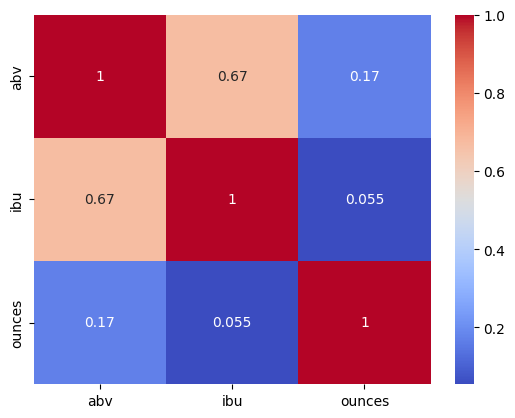

In [104]:
sns.heatmap(beer[["abv","ibu","ounces"]].corr(), annot=True, cmap="coolwarm")
#la escala no es cocrrecta, los colores mas claros son los cercanos a 0 y no son los que queremos que destaque

<Axes: >

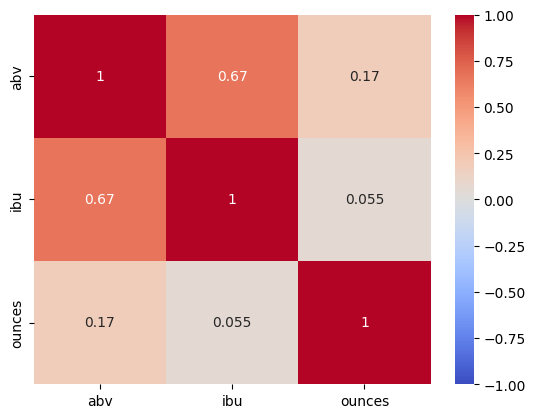

In [ ]:
sns.heatmap(beer[["abv","ibu","ounces"]].corr(), annot=True, cmap="coolwarm",vmin=-1)
#ponemos vmin=-1 ya que si no, nos toma los valores menos destacados los mas importantes

Vemos que cuanto mayor es "ounces"(tamaño) mayor es "ibu"(amargor), al igual que "abv"(%alcohol)

id nos da el identificador de la cerveza y brewery_id el identificador de la cerveceria que produce cada cerveza

<Axes: xlabel='ibu', ylabel='ounces'>

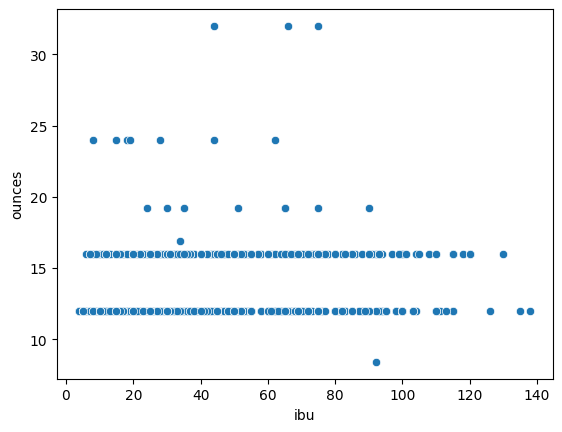

In [26]:
sns.scatterplot( x=beer["ibu"], y=beer["ounces"] )

<Axes: xlabel='abv', ylabel='ounces'>

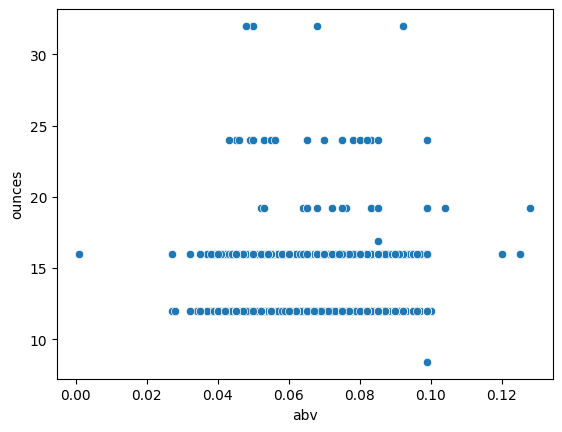

In [27]:
sns.scatterplot( x=beer["abv"], y=beer["ounces"] )

<Axes: xlabel='abv', ylabel='ibu'>

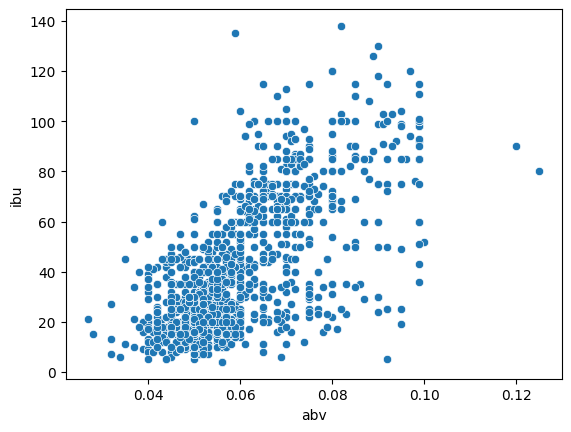

In [28]:
sns.scatterplot( x=beer["abv"], y=beer["ibu"] )
#en este caso si que parece que existe una relacion lineal entre la cantidad de alcohol y el amargor de la cerveza

Con el resto de datos numericos no los consideramos por ser identificadores

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

'Se trata de una distribucion ligeramente desplazada a la izquierda de la mediana, \n    sin embargo vemos que a la derecha tenemos valores que sobresalen\n    Podriamos considerar que es simetrica'

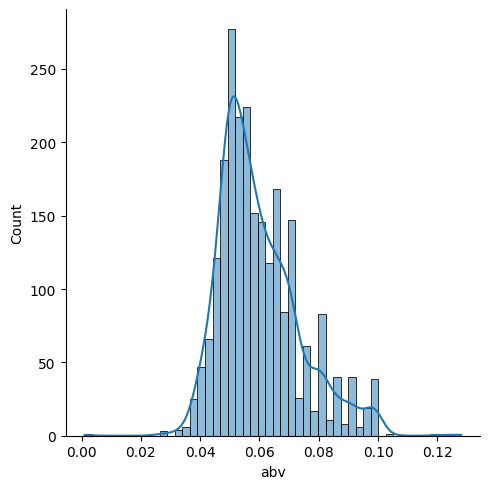

In [29]:
sns.displot( data=beer["abv"], kde=True )
'''Se trata de una distribucion ligeramente desplazada a la izquierda de la mediana, 
    sin embargo vemos que a la derecha tenemos valores que sobresalen
    Podriamos considerar que es simetrica'''

In [105]:
#cuantificamos la simetria
beer["abv"].skew()
#tenemos un coeficiente de asimetria positiva donde la cola se alarga a la derecha CAF>0

np.float64(0.9584771340361382)

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

<Axes: ylabel='abv'>

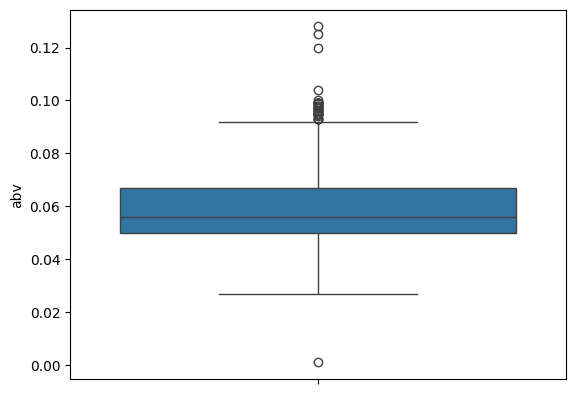

In [106]:
sns.boxplot( data=beer["abv"])

La cerveza sin nos da un valor alejado
Las cervezas con cantidades de alcohol altes nos dan los datos mas alejados

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [31]:
len(beer["style"].unique())

100

In [114]:
beer.groupby("style")[["abv"]].mean().sort_values(by="abv", ascending=False)
#agrupamos los estilos, le aplicamos solo la columna "abv" y la seleccionamos para hacer la media
# Reordenamos por orden descendete las medias de "abv" para cada estilo, de este modo quedan arriba las mayores

,abv
style,
English Barleywine,0.107667
Quadrupel (Quad),0.104000
American Barleywine,0.099000
American Malt Liquor,0.099000
Russian Imperial Stout,0.097636
...,...
Berliner Weissbier,0.043909
English Dark Mild Ale,0.041500
Light Lager,0.040417


In [116]:
beer.groupby("style")[["abv"]].aggregate(["mean","count"]).sort_values()[0:10]

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [33]:
beer.groupby("style")[["ibu"]].mean().sort_values(by="ibu", ascending=False)

,ibu
style,
American Barleywine,96.00
American Double / Imperial IPA,93.32
Russian Imperial Stout,86.50
American Double / Imperial Pilsner,85.00
Belgian Strong Dark Ale,72.00
...,...
Kristalweizen,NaN
Low Alcohol Beer,NaN
Mead,NaN


## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [34]:
breweries = pd.read_csv("data/datasets_breweries.csv")
breweries

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [35]:
breweries=breweries.rename(columns={'Unnamed: 0': 'brewery_id',"name":"brewery_name"})
breweries


,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [117]:
new_df=pd.merge(beer,breweries, on= "brewery_id",how="outer")
new_df

,abv,ibu,id,name,style,brewery_id,ounces,ibu_y,ibu_imp,brewery_name,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,67.634551,50.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,25.166667,26.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,23.200000,19.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,24.818182,38.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,31.923077,25.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...,...,...
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,17.592593,35.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,67.634551,35.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,25.166667,35.0,Butternuts Beer and Ale,Garrattsville,NY
2408,0.043,NaN,49,Porkslap Pale Ale,American Pale Ale (APA),556,12.0,44.941176,35.0,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [37]:
len(new_df["state"].drop_duplicates())

51

In [38]:
len(new_df["city"].drop_duplicates())

384

In [119]:
new_df["brewery_id"].nunique()#tenemos que coger el identificador, ya que con nombre pueden salirme cervecerias distintas(en distintas ciudades pj) con el mismo nombre pero distinto id


558

In [124]:

cervecerias=new_df.groupby("brewery_name")["brewery_id"].nunique().sort_values(ascending=False)
cervecerias[cervecerias>1]
#efectivamente tenemos 7 cervecerias que es la diferencia entre nunique de b_name(551) y b_id(558)

brewery_name
Blackrocks Brewery         2
Blue Mountain Brewery      2
Lucette Brewing Company    2
Oskar Blues Brewery        2
Otter Creek Brewing        2
Sly Fox Brewing Company    2
Summit Brewing Company     2
Name: brewery_id, dtype: int64

## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [125]:
new_df.groupby(["state","city"])["abv"].aggregate(["mean","median","max","count"])

mean  median    max  count
state city                                      
AK    Anchorage   0.054200  0.0520  0.063     15
      Juneau      0.053000  0.0530  0.053      2
      Soldotna    0.058500  0.0580  0.068      4
      Talkeetna   0.059500  0.0585  0.065      4
AL    Birmingham  0.065400  0.0600  0.093      5
...                    ...     ...    ...    ...
WI    Wilson      0.055000  0.0550  0.055      1
WV    Lewisburg   0.062000  0.0620  0.067      2
WY    Jackson     0.054857  0.0520  0.068      7
      Pinedale    0.061000  0.0610  0.072      2
      Sheridan    0.052833  0.0480  0.070      6

[401 rows x 4 columns]

In [126]:
new_df.groupby(["state","city"])["abv"].aggregate(["mean","median","max","count"]).loc[" WY"]

,mean,median,max,count
city,,,,
Jackson,0.054857,0.052,0.068,7
Pinedale,0.061000,0.061,0.072,2
Sheridan,0.052833,0.048,0.070,6


## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [41]:

ejer_21=new_df[new_df["state"]== " IN"].sort_values(by= "ibu",ascending=False)
ejer_21["name"].head()
#[new_df["state"].srt.contain("IN")] si contiene este string me da igual si tiene  espacion o no, solo necesito que contenga esas dos letras


479          Hopkick Dropkick
2191    Overlord Imperial IPA
811            Half Cycle IPA
2062                     Isis
2189                     Csar
Name: name, dtype: object

## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [127]:
new_df.groupby("city")[["ibu_imp"]].describe()#si lo hacemos sin NaN usamos ibu_imp si no solo con ibu
#la desviacion estandar de un unico valor es 0=NAN

ibu_imp                                                       \
                 count        mean        std    min     25%    50%     75%   
city                                                                          
Abingdon           1.0  135.000000        NaN  135.0  135.00  135.0  135.00   
Abita Springs      3.0   27.333333  21.455380   13.0   15.00   17.0   34.50   
Ada                1.0   35.000000        NaN   35.0   35.00   35.0   35.00   
Afton              4.0   43.000000  19.899749   22.0   28.00   45.0   60.00   
Airway Heights     5.0   35.000000   0.000000   35.0   35.00   35.0   35.00   
...                ...         ...        ...    ...     ...    ...     ...   
Woodinville        4.0   46.750000  18.643587   27.0   39.75   44.0   51.00   
Worcester          1.0   69.000000        NaN   69.0   69.00   69.0   69.00   
Yakima             2.0   54.000000  22.627417   38.0   46.00   54.0   62.00   
Yardley            1.0   35.000000        NaN   35.0   35.00   35.0   35.00   
York               4.0   44.250000  22.779742   20.0   35.00   41.0   50.25   

                       
                  max  
city                   
Abingdon        135.0  
Abita Springs    52.0  
Ada              35.0  
Afton            60.0  
Airway Heights   35.0  
...               ...  
Woodinville      72.0  
Worcester        69.0  
Yakima           70.0  
Yardley          35.0  
York             75.0  

[384 rows x 8 columns]

In [128]:
#La moda me devuelve una serie de lementos, no puedo usarla el un aggregate, los otros estadisticos son valores unicos
new_df.groupby("city")[["ibu_imp"]].aggregate(pd.Series.mode)
# en algunos valores nos dara una serie de resultados y en otros valores unicos

,ibu_imp
city,
Abingdon,135.0
Abita Springs,"[13.0, 17.0, 52.0]"
Ada,35.0
Afton,60.0
Airway Heights,35.0
...,...
Woodinville,44.0
Worcester,69.0
Yakima,"[38.0, 70.0]"


## Ejercicio 23
Consigue en un DataFrame todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [ ]:
#1 listado de cervezas
    #2 Tiene que pertenecer a una serie de cervecerias
        #3 en esas cervecerias tiene que haber al menos una con 0.07 o mas
'''NOS PREGUNTAN POR LOS MAXIMOS NO LOS MINIMOS'''

cervec = new_df[new_df["abv"]>=0.07]["brewery_id"].unique()#la condicion es l cerveceria no la cerveza, pueden salirme cervezas de menor graduacion pero pq en esa cerveceria tambien hay cervezas que cumplen la condicion
new_df[new_df["brewery_id"].isin(cervec)]

,abv,ibu,id,name,style,brewery_id,ounces,ibu_y,ibu_imp,brewery_name,city,state
6,0.080,68.0,2686,Citra Ass Down,American Double / Imperial IPA,1,16.0,93.320000,68.0,Against the Grain Brewery,Louisville,KY
7,0.125,80.0,2685,London Balling,English Barleywine,1,16.0,66.666667,80.0,Against the Grain Brewery,Louisville,KY
8,0.077,25.0,2684,35 K,Milk / Sweet Stout,1,16.0,25.166667,25.0,Against the Grain Brewery,Louisville,KY
9,0.042,42.0,2683,A Beer,American Pale Ale (APA),1,16.0,44.941176,42.0,Against the Grain Brewery,Louisville,KY
10,0.050,25.0,2682,Rules are Rules,German Pilsener,1,16.0,34.176471,25.0,Against the Grain Brewery,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...
2347,0.062,42.0,28,Tule Duck Red Ale (Current),American Amber / Red Ale,530,16.0,36.298701,42.0,Buckbean Brewing Company,Reno,NV
2348,0.058,35.0,27,Original Orange Blossom Ale (Current),Herbed / Spiced Beer,530,16.0,22.200000,35.0,Buckbean Brewing Company,Reno,NV
2349,0.052,40.0,26,Black Noddy Lager (Current),Schwarzbier,530,16.0,31.000000,40.0,Buckbean Brewing Company,Reno,NV
2396,0.072,NaN,324,Wyoming Pale Ale,American Pale Ale (APA),550,16.0,44.941176,35.0,Wind River Brewing Company,Pinedale,WY


In [131]:
'''OTRA FORMA'''
cervecerias=new_df.groupby("brewery_id")["abv"].max()#cojo los maximos
cervecerias

brewery_id
0      0.060
1      0.125
2      0.072
3      0.080
4      0.063
       ...  
553    0.050
554    0.055
555    0.055
556    0.068
557    0.049
Name: abv, Length: 558, dtype: float64

In [132]:
cervecerias = cervecerias[cervecerias >= 0.07].index# le aplic la condicion
cervecerias

Index([  1,   2,   3,   5,   6,   7,   8,  10,  12,  15,
       ...
       507, 509, 514, 515, 521, 522, 523, 524, 530, 550],
      dtype='int64', name='brewery_id', length=227)

In [133]:

new_df[new_df["brewery_id"].isin(cervecerias)]# en el df le paso el filtro de cevecerias

,abv,ibu,id,name,style,brewery_id,ounces,ibu_y,ibu_imp,brewery_name,city,state
6,0.080,68.0,2686,Citra Ass Down,American Double / Imperial IPA,1,16.0,93.320000,68.0,Against the Grain Brewery,Louisville,KY
7,0.125,80.0,2685,London Balling,English Barleywine,1,16.0,66.666667,80.0,Against the Grain Brewery,Louisville,KY
8,0.077,25.0,2684,35 K,Milk / Sweet Stout,1,16.0,25.166667,25.0,Against the Grain Brewery,Louisville,KY
9,0.042,42.0,2683,A Beer,American Pale Ale (APA),1,16.0,44.941176,42.0,Against the Grain Brewery,Louisville,KY
10,0.050,25.0,2682,Rules are Rules,German Pilsener,1,16.0,34.176471,25.0,Against the Grain Brewery,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...
2347,0.062,42.0,28,Tule Duck Red Ale (Current),American Amber / Red Ale,530,16.0,36.298701,42.0,Buckbean Brewing Company,Reno,NV
2348,0.058,35.0,27,Original Orange Blossom Ale (Current),Herbed / Spiced Beer,530,16.0,22.200000,35.0,Buckbean Brewing Company,Reno,NV
2349,0.052,40.0,26,Black Noddy Lager (Current),Schwarzbier,530,16.0,31.000000,40.0,Buckbean Brewing Company,Reno,NV
2396,0.072,NaN,324,Wyoming Pale Ale,American Pale Ale (APA),550,16.0,44.941176,35.0,Wind River Brewing Company,Pinedale,WY


## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [44]:
len(new_df["state"].unique())

51

In [ ]:
#LISTADO DE CERVEZAS
# FILTRO POR ESTADOS
#  LA MEDIA DE LAS CERVEZAS DEL ESTADO, TIENE QUE ESTAR POR ENCIMA DE LA MEDIA GENERAL

In [45]:
media=new_df["ibu"].mean()#sacamos la media del amargor de las cervezas

ejer_24=new_df.groupby(["state","name"])["ibu"].aggregate("mean")#agrupa los estados, coge la columna de (ibu) y haz la media
ejer_24[ejer_24>media]


state  name                 
AK     Chuli Stout              55.0
       Fairweather IPA          64.0
       King Street IPA          70.0
       Mother Ale               46.0
       Pleasure Town            61.0
                                ... 
WV     Mothman Black IPA        71.0
       Wild Trail Pale Ale      44.0
WY     Indian Paintbrush IPA    75.0
       Pako’s EyePA             60.0
       Snow King Pale Ale       55.0
Name: ibu, Length: 552, dtype: float64

In [137]:
ejer_2=new_df.groupby("state")["ibu"].mean()#media de amargor de los estados
x=ejer_2[ejer_2>media]

In [138]:
new_df[new_df["state"].isin(x)]

,abv,ibu,id,name,style,brewery_id,ounces,ibu_y,ibu_imp,brewery_name,city,state
